# Super resolution of MNIST digits

In [1]:
from torchvision import datasets, transforms
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import torch.nn.functional as F
from functools import partial
from scipy import sparse
import numpy as np
import torch
from tqdm import tqdm
import os
from VDSR.model import VDSR
from VDSR.data import poisson_noise
from scipy.ndimage import binary_dilation



from utils import downsample_gaussian_meanpool, ImageOnlyDataset, auto_labeling_MNIST, get_distance
from accuracy_bounds.inverseproblems.feasible_sets_dataloader import distsYY_withineps_dataloader_cuda
from accuracy_bounds.inverseproblems.kersize_compute_dataloader import target_distances_cuda_V2
from accuracy_bounds.inverseproblems.utils import torch_csr_to_scipy

Define some useful functions

In [2]:
def DS_operator_formatrix(img, intermediate_op):
    """
    Apply a downsampling operator to an image after padding.

    Args:
        img (torch.Tensor): Input image tensor.
        intermediate_op (callable): Downsampling operator.

    Returns:
        torch.Tensor: Downsampled image.
    """
    img_padded = F.pad(img.unsqueeze(0), (4, 4, 4, 4), mode='reflect').squeeze()
    DS_img = intermediate_op(img_padded)
    return DS_img

def load_model(vdsr_model, weights_path, device):
    """
    Load model weights from a checkpoint.

    Args:
        vdsr_model (torch.nn.Module): VDSR model instance.
        weights_path (str): Path to model weights.
        device (str): Device to load the model on.

    Returns:
        torch.nn.Module: Model with loaded weights.
    """
    ckpt = torch.load(weights_path, map_location=device)
    vdsr_model.load_state_dict(ckpt, strict=True)
    vdsr_model.to(device)
    vdsr_model.eval()
    return vdsr_model

def process_MNIST_VDSR_batch(batch):
    """
    Preprocess a batch of MNIST images for VDSR.

    Args:
        batch (torch.Tensor): Input batch.

    Returns:
        torch.Tensor: Processed batch.
    """
    batch = batch.unsqueeze(1)
    batch = F.interpolate(
        batch,
        size=(28, 28),
        mode="bilinear",
        align_corners=False
    ).float()
    return batch


Set the necessary parametrs and the filepaths

In [3]:
# Configuration
MNIST_folder = '/localhome/iaga_dv/Dokumente/MNIST_data'  # Example path; replace with your local path
scale_factor = 3 # Downsampling factor
filter = 'gaussian'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_type = 'eps06'  # Choose the model: 'noiseless', 'eps03', 'eps06', 'all_digits_eps06'

# Model weights paths (example paths; replace with your local paths)
model_weights = {
    'noiseless': '/localhome/iaga_dv/Dokumente/AccuracyBounds/examples/MNIST/VDSR/ckp/models/model_best.pth',
    'eps03': '/localhome/iaga_dv/Dokumente/AccuracyBounds/examples/MNIST/VDSR/ckp_poisson_digi143/models/model_best.pth',
    'eps06': '/localhome/iaga_dv/Dokumente/AccuracyBounds/examples/MNIST/VDSR/ckp_bigpoisson_digi143/models/model_best.pth',
    'all_digits_eps06': '/localhome/iaga_dv/Dokumente/AccuracyBounds/examples/MNIST/VDSR/ckp_bigpoisson/models/model_best.pth'
}
vdsr_weights_path = model_weights[model_type]

# Initialize model
vdsr_model = VDSR()
model = load_model(vdsr_model, vdsr_weights_path, device=device)

# Downsampling operator
intermediate_operator_formatrix = partial(downsample_gaussian_meanpool, factor=scale_factor)
DS_for_matrix = partial(DS_operator_formatrix, intermediate_op=intermediate_operator_formatrix)
p_Y = 2
p_X = 1


In [4]:
# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.squeeze(0))
])

transform_DS = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.squeeze(0)),
    transforms.Lambda(lambda x: DS_for_matrix(x))
])

# Load datasets
HR_dataset = datasets.MNIST(
    root=MNIST_folder,
    train=False,
    download=True,
    transform=transform
)

DS_dataset = datasets.MNIST(
    root=MNIST_folder,
    train=False,
    download=True,
    transform=transform_DS
)

HR_dataset_train = datasets.MNIST(
    root=MNIST_folder,
    train=True,
    download=True,
    transform=transform
)

dataloader_HR_train = DataLoader(HR_dataset_train, batch_size=100, shuffle=False, drop_last=False)



## Inference on the MNIST test data

Img 18: Consistency DS(SR)-LR: 0.231


/tmp/ipykernel_503022/110806062.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  delta_patch_1 = get_distance(torch.tensor(img1_HR), torch.tensor(img1_SR), method='l1', agg_method='patch', patch_size=3)


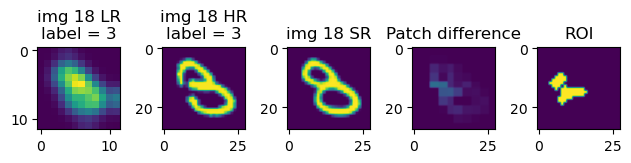

Img 27: Consistency DS(SR)-LR: 0.199


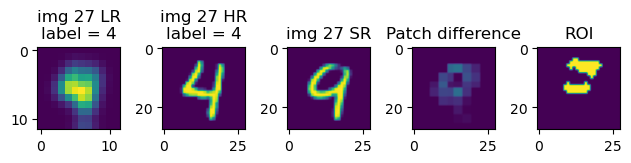

Img 87: Consistency DS(SR)-LR: 0.322


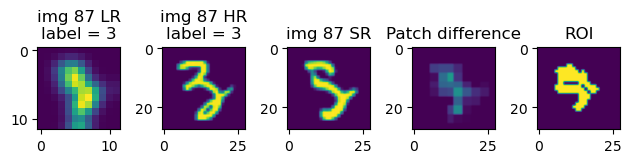

In [5]:
# Example inference and visualization
list_idx_hall = [18, 27, 87]  # Example indices for hallucination analysis
threshold_patch_dist = 0.65

for i in list_idx_hall:
    img1_LR, label1 = DS_dataset[i]
    img1_HR, label1 = HR_dataset[i]

    # Super-resolution
    batch_LR = np.stack([img1_LR], axis=0)
    batch_LR = process_MNIST_VDSR_batch(torch.tensor(batch_LR))
    preds = model(batch_LR).mean(axis=1).detach().cpu().numpy()
    img1_SR = preds[0]
    DS_SR1 = DS_for_matrix(torch.tensor(img1_SR))
    consistency_1 = np.linalg.norm((DS_SR1 - img1_LR), ord=p_Y)

    print(f'Img {i}: Consistency DS(SR)-LR: {np.round(consistency_1, 3)}')

    # Patch distance and ROI
    delta_patch_1 = get_distance(torch.tensor(img1_HR), torch.tensor(img1_SR), method='l1', agg_method='patch', patch_size=3)
    hall_label1 = delta_patch_1 > threshold_patch_dist
    structure = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=int)
    ROI_1 = auto_labeling_MNIST(img1_HR, img1_SR)
    ROI_1 = binary_dilation(ROI_1, structure=structure, iterations=1)

    if ROI_1.sum() == 0:
        img1_bin = (np.array(img1_HR) > 0).astype(float)
        ROI_1 = binary_dilation(img1_bin, structure=structure, iterations=1)

    # Visualization
    fig, axes = plt.subplots(1, 5)
    axes[0].imshow(img1_LR); axes[0].set_title(f'img {i} LR\nlabel = {label1}')
    axes[1].imshow(img1_HR); axes[1].set_title(f'img {i} HR\nlabel = {label1}')
    axes[2].imshow(img1_SR); axes[2].set_title(f'img {i} SR')
    axes[3].imshow(delta_patch_1, vmin=0, vmax=img1_HR.max()-img1_HR.min()); axes[3].set_title('Patch difference')
    axes[4].imshow(ROI_1); axes[4].set_title('ROI')
    plt.tight_layout()
    plt.show()


## Verification of the hallucination definition

/tmp/ipykernel_503022/3761663406.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_det_norm_1 = torch.norm((torch.tensor(img1_HR) - img1_SR) * ROI_1, p=p_X) / ROI_1.sum()
  0%|          | 0/50 [00:00<?, ?it/s]/localhome/iaga_dv/Dokumente/AccuracyBounds/examples/MNIST/VDSR/data.py:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(noisy_img)
100%|██████████| 50/50 [00:00<00:00, 53.89it/s]


Number of valid preds for img 18: 50
x_det norm for img 18 = 0.847000002861023
Img 18: Min Dist to HR in ROI (eta_max): 0.847000002861023
Max Dist to x_det in ROI (eta_min): 0.3499999940395355


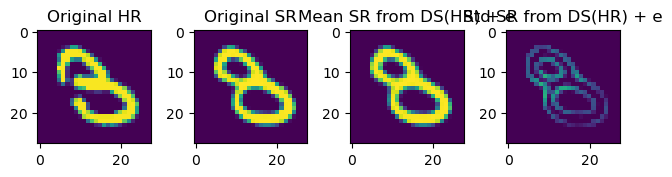

100%|██████████| 50/50 [00:01<00:00, 42.91it/s]


Number of valid preds for img 27: 50
x_det norm for img 27 = 0.902999997138977
Img 27: Min Dist to HR in ROI (eta_max): 0.902999997138977
Max Dist to x_det in ROI (eta_min): 0.7049999833106995


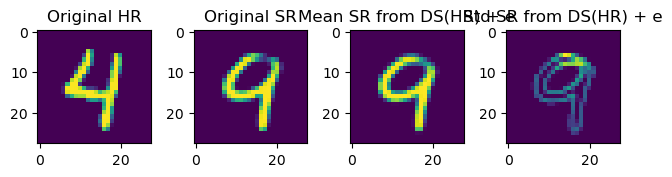

100%|██████████| 50/50 [00:00<00:00, 51.39it/s]


Number of valid preds for img 87: 50
x_det norm for img 87 = 1.1319999694824219
Img 87: Min Dist to HR in ROI (eta_max): 1.1319999694824219
Max Dist to x_det in ROI (eta_min): 0.6150000095367432


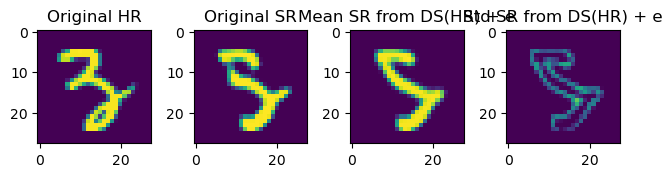

In [6]:
# Noise analysis
list_idx_hall = [18, 27, 87]
n_preds = 50
noise_level = 0.3

for i in list_idx_hall:
    img1_LR, label1 = DS_dataset[i]
    img1_HR, label1 = HR_dataset[i]

    # Super-resolution
    batch_LR = np.stack([img1_LR], axis=0)
    batch_LR = process_MNIST_VDSR_batch(torch.tensor(batch_LR))
    preds = model(batch_LR).mean(axis=1).detach().cpu().numpy()
    img1_SR = preds[0]
    DS_SR1 = DS_for_matrix(torch.tensor(img1_SR))
    consistency_1 = np.linalg.norm((DS_SR1 - img1_LR), ord=p_Y)

    # ROI
    ROI_1 = auto_labeling_MNIST(img1_HR, img1_SR)
    ROI_1 = binary_dilation(ROI_1, structure=structure, iterations=1)
    if ROI_1.sum() == 0:
        img1_bin = (np.array(img1_HR) > 0).astype(float)
        ROI_1 = binary_dilation(img1_bin, structure=structure, iterations=1)

    # Distances
    dist_to_HR_1 = torch.norm((torch.tensor(img1_SR) - img1_HR) * ROI_1, p=p_X) / ROI_1.sum()
    dist_to_xdet_1 = torch.norm((torch.tensor(img1_SR) - img1_SR) * ROI_1, p=p_X) / ROI_1.sum()
    x_det_norm_1 = torch.norm((torch.tensor(img1_HR) - img1_SR) * ROI_1, p=p_X) / ROI_1.sum()

    # Noise loop
    dists_to_HR_noisy_1 = []
    dists_to_xdet_noisy_1 = []
    preds_fromnoisy_1 = []
    for k in tqdm(range(n_preds)):
        noisy_1 = poisson_noise(torch.tensor(DS_SR1), target_norm=noise_level)
        batch_LR = np.stack([noisy_1], axis=0)
        batch_LR = process_MNIST_VDSR_batch(torch.tensor(batch_LR))
        preds = model(batch_LR).mean(axis=1).detach().cpu().numpy()
        img1_SR_fromnoisy = preds[0]
        dist_to_HR_noisy_1 = torch.norm((torch.tensor(img1_SR_fromnoisy) - img1_HR) * ROI_1, p=p_X) / ROI_1.sum()
        dist_to_xdet_noisy_1 = torch.norm((torch.tensor(img1_SR_fromnoisy) - img1_SR) * ROI_1, p=p_X) / ROI_1.sum()

        if dist_to_HR_noisy_1 > dist_to_xdet_noisy_1:
            dists_to_HR_noisy_1.append(dist_to_HR_noisy_1)
            dists_to_xdet_noisy_1.append(dist_to_xdet_noisy_1)
            preds_fromnoisy_1.append(img1_SR_fromnoisy)

    # Handle empty results
    if len(preds_fromnoisy_1) == 0:
        preds_fromnoisy_1 = np.zeros((1, 28, 28))
        dists_to_HR_noisy_1 = [0]
        dists_to_xdet_noisy_1 = [0]
    else:
        preds_fromnoisy_1 = np.stack(preds_fromnoisy_1, axis=0)

    # Statistics and visualization
    avg_pred_1 = preds_fromnoisy_1.mean(axis=0)
    std_pred_1 = preds_fromnoisy_1.std(axis=0)
    print(f'Number of valid preds for img {i}: {preds_fromnoisy_1.shape[0]}')
    print(f'x_det norm for img {i} = {np.round(x_det_norm_1, 3)}')
    print(f'Img {i}: Min Dist to HR in ROI (eta_max): {np.round(min(min(dists_to_HR_noisy_1), x_det_norm_1), 3)}')
    print(f'Max Dist to x_det in ROI (eta_min): {np.round(max(dists_to_xdet_noisy_1), 3)}')

    fig, axes = plt.subplots(1, 4)
    axes[0].imshow(img1_HR); axes[0].set_title('Original HR')
    axes[1].imshow(img1_SR); axes[1].set_title('Original SR')
    axes[2].imshow(avg_pred_1); axes[2].set_title('Mean SR from DS(HR) + e')
    axes[3].imshow(3*std_pred_1, vmin=0, vmax=avg_pred_1.max()); axes[3].set_title('Std SR from DS(HR) + e')
    plt.tight_layout()
    plt.show()

    plt.show()

# Compute the distances between the LR images
Only store those under a given threshold to save memory

In [7]:
# Distance matrix calculation
epsilon_max = 0.6
save_folder = f'{MNIST_folder}/results'
os.makedirs(save_folder, exist_ok=True)

# Load training dataset
DS_dataset = datasets.MNIST(
    root=MNIST_folder,
    train=True,
    download=True,
    transform=transform_DS
)
DS_dataset = ImageOnlyDataset(DS_dataset)
DS_loader1 = DataLoader(DS_dataset, batch_size=500, shuffle=False, drop_last=False)
DS_loader2 = DataLoader(DS_dataset, batch_size=500, shuffle=False, drop_last=False)

print(f'Calculating distsYY under epsilon = {epsilon_max}')
distsYY = distsYY_withineps_dataloader_cuda(DS_loader1, DS_loader2, p_Y=2, epsilon=epsilon_max)
distsYY_save = torch_csr_to_scipy(distsYY.cpu().to_sparse_csr())
sparse.save_npz(os.path.join(save_folder, f'distsYY_MNIST_all_eps0{int(10*epsilon_max)}'), distsYY_save)



Calculating distsYY under epsilon = 0.6


/localhome/iaga_dv/Dokumente/AccuracyBounds/src/accuracy_bounds/inverseproblems/feasible_sets_dataloader.py:68: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  forwarded_target = torch.tensor(forwarded_target, dtype = torch.float32, device = device)
/localhome/iaga_dv/Dokumente/AccuracyBounds/src/accuracy_bounds/inverseproblems/feasible_sets_dataloader.py:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_data = torch.tensor(input_data, dtype = torch.float32, device = device)
/localhome/iaga_dv/Dokumente/AccuracyBounds/src/accuracy_bounds/inverseproblems/feasible_sets_dataloader.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone()

KeyboardInterrupt: 

## Explore the closest LR images to each other

  2%|▏         | 26431/1650818 [00:00<00:06, 263172.05it/s]

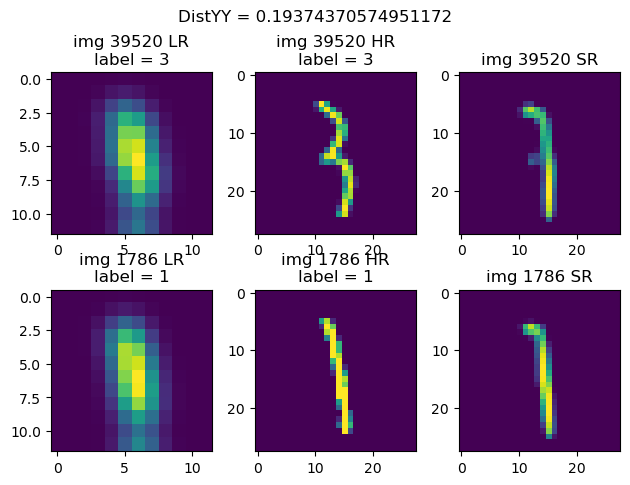

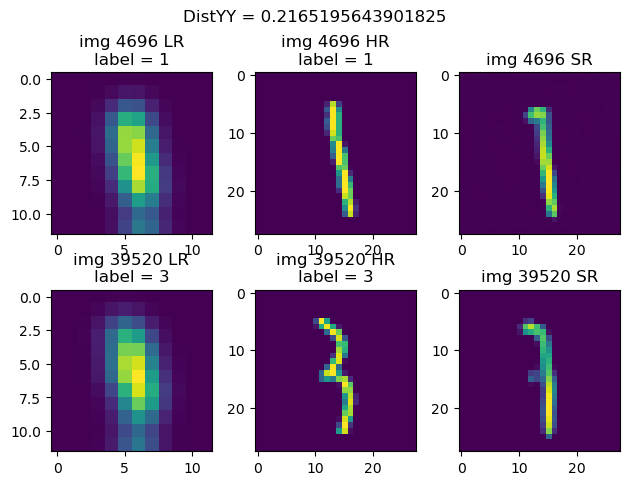

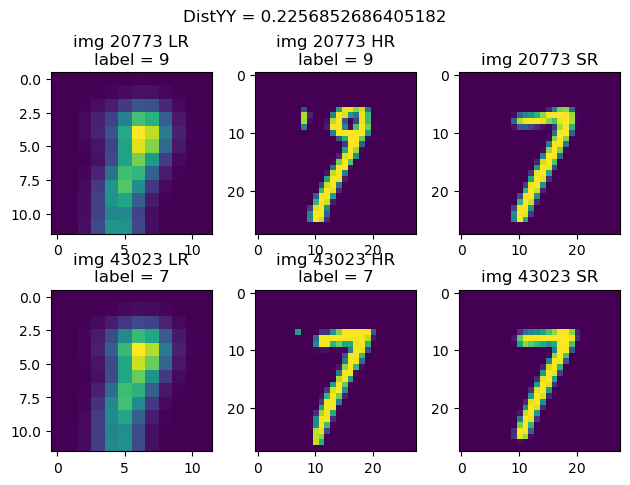

  3%|▎         | 53162/1650818 [00:30<21:51, 1218.03it/s]  

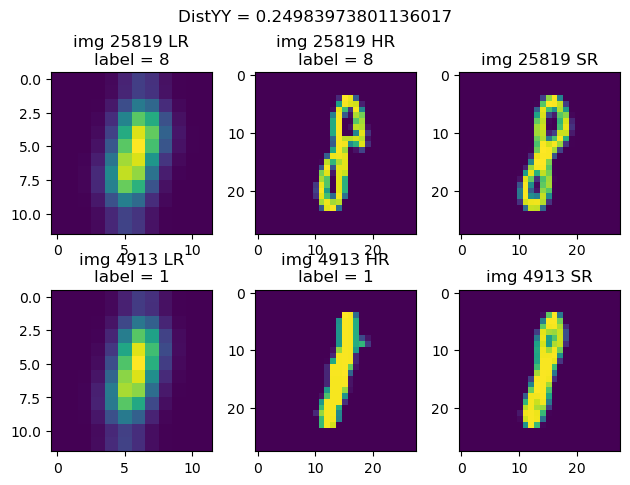

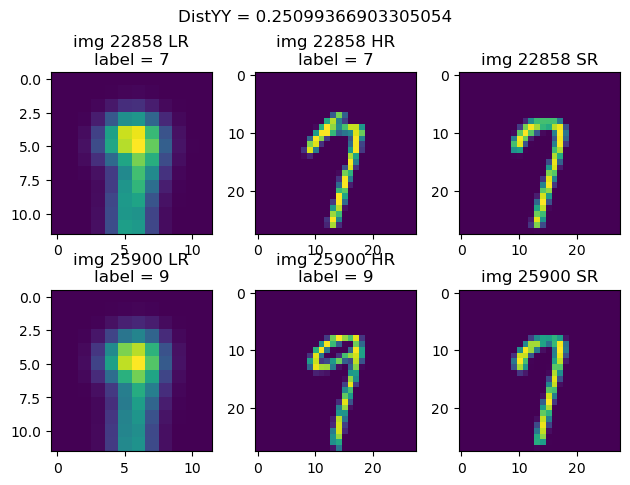

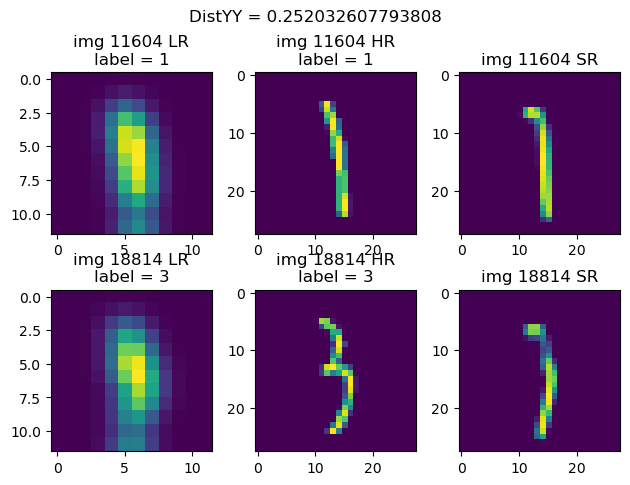

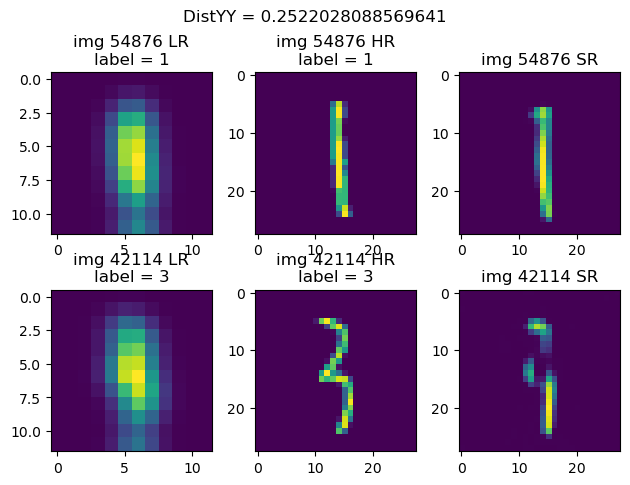

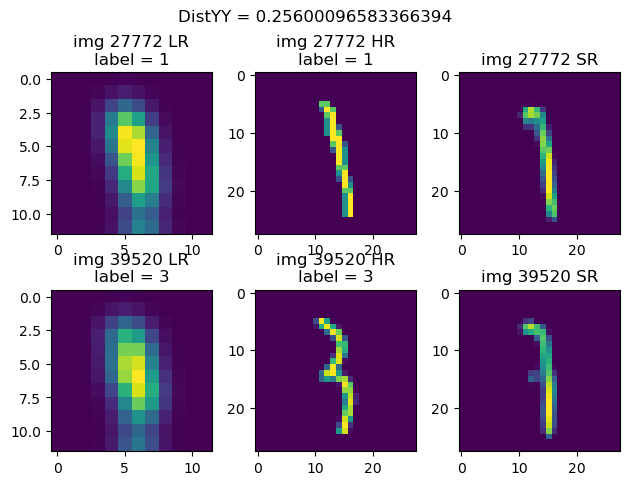

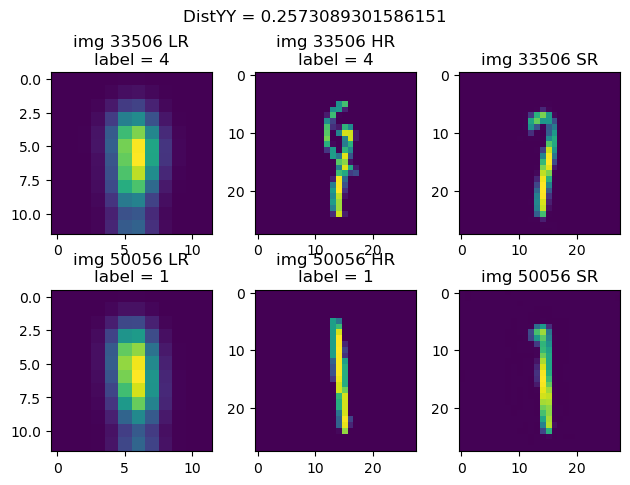

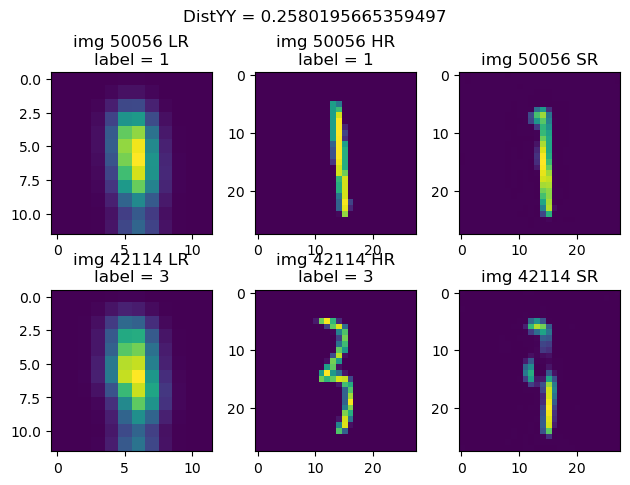

  4%|▎         | 59133/1650818 [00:44<34:05, 778.03it/s] 

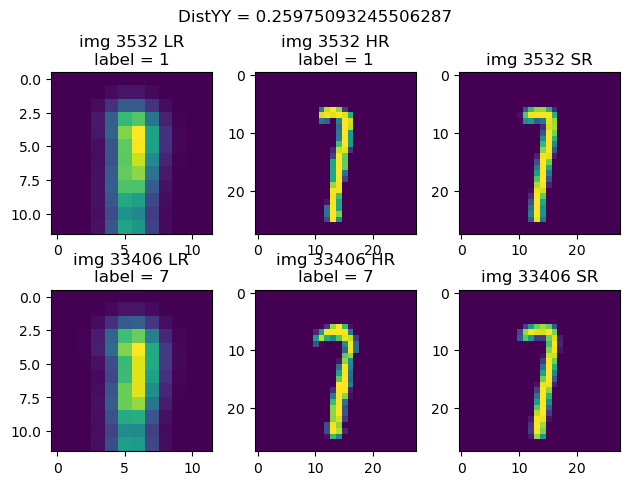

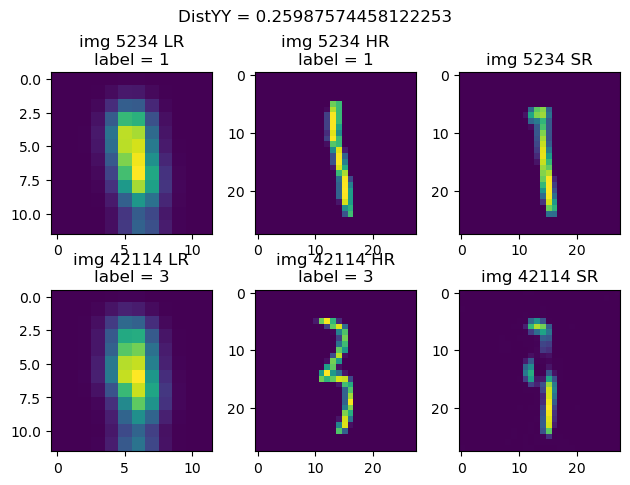

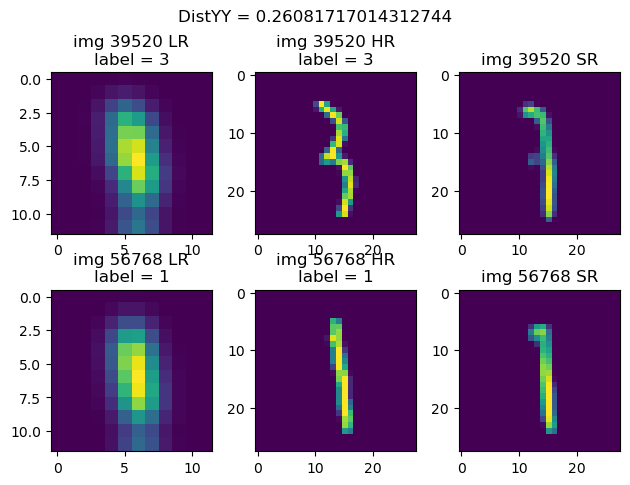

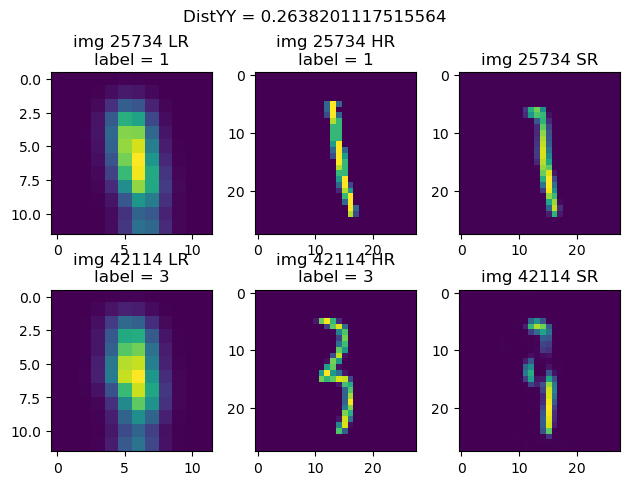

  4%|▍         | 66613/1650818 [00:59<42:55, 615.01it/s]

In [ ]:
# Feasible set analysis
distsYY = sparse.load_npz(f'{MNIST_folder}/results/distsYY_MNIST_all_eps06.npz')
feasapp = distsYY > 0

HR_dataset = datasets.MNIST(
    root=MNIST_folder,
    train=True,
    download=True,
    transform=transform
)
DS_dataset = datasets.MNIST(
    root=MNIST_folder,
    train=True,
    download=True,
    transform=transform_DS
)

# Visualize pairs with different labels but close in downsampled space
visited = []
plotted = []
values = distsYY.data
col_indices = distsYY.indices
row_indices = np.repeat(np.arange(distsYY.shape[0]), np.diff(distsYY.indptr))
sorted_indices = np.argsort(values)

for i in tqdm(range(len(values))):
    idx_arr = sorted_indices[i]
    value = values[idx_arr]
    idx1, idx2 = row_indices[idx_arr], col_indices[idx_arr]

    if idx1 != idx2 and set([idx1, idx2]) not in visited:
        visited.append(set([idx1, idx2]))
        img1_HR, label1 = HR_dataset[idx1]
        img2_HR, label2 = HR_dataset[idx2]
        img1_LR, label1 = DS_dataset[idx1]
        img2_LR, label2 = DS_dataset[idx2]

        if label1 != label2:
            plotted.append(idx1)
            plotted.append(idx2)
            batch_LR = np.stack([img1_LR, img2_LR], axis=0)
            batch_LR = process_MNIST_VDSR_batch(torch.tensor(batch_LR))
            preds = model(batch_LR).mean(axis=1).detach().cpu().numpy()
            img1_SR = preds[0]
            img2_SR = preds[1]

            fig, axes = plt.subplots(2, 3)
            axes[0, 0].imshow(img1_LR); axes[0, 0].set_title(f'img {idx1} LR\nlabel = {label1}')
            axes[0, 1].imshow(img1_HR); axes[0, 1].set_title(f'img {idx1} HR\nlabel = {label1}')
            axes[0, 2].imshow(img1_SR); axes[0, 2].set_title(f'img {idx1} SR')
            axes[1, 0].imshow(img2_LR); axes[1, 0].set_title(f'img {idx2} LR\nlabel = {label2}')
            axes[1, 1].imshow(img2_HR); axes[1, 1].set_title(f'img {idx2} HR\nlabel = {label2}')
            axes[1, 2].imshow(img2_SR); axes[1, 2].set_title(f'img {idx2} SR')
            fig.suptitle(f'DistYY = {value}')
            plt.tight_layout()
            plt.show()

        if len(plotted) > 50:
            break


## Compute the kernelsize for a given epsilon

### First compute the distances between images in the same feasible set

In [13]:
# Kernel size calculation
epsilon = 0.6
distsYY_copy = sparse.load_npz(f'{MNIST_folder}/results/distsYY_MNIST_all_eps06.npz').tocsr()
data = distsYY_copy.data
for i in range(data.size):
    if data[i] > epsilon:
        data[i] = 0
distsYY_copy.eliminate_zeros()
distsYY_copy.data[:] = 1
feasapp = distsYY_copy

HR_dataset = ImageOnlyDataset(datasets.MNIST(
    root=MNIST_folder,
    train=True,
    download=True,
    transform=transform
))
HR_loader1 = DataLoader(HR_dataset, batch_size=500, shuffle=False, drop_last=False)
HR_loader2 = DataLoader(HR_dataset, batch_size=500, shuffle=False, drop_last=False)

distsXX = target_distances_cuda_V2(HR_loader1, feasapp, p_X=1, batchsize=5000)
torch.save(distsXX, f'{MNIST_folder}/results/distsXX_MNISTalls_eps0{int(10*epsilon)}.pt')


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7ac4475ebcd0>>
Traceback (most recent call last):
  File "/localhome/iaga_dv/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

### Then get the kersize, and see the pair of images corresponding to the kernelsize

epsilon  =  0.6 
 Worst Case Kersize = 0.44841042160987854
Rank 1: distXX = 36.47911834716797


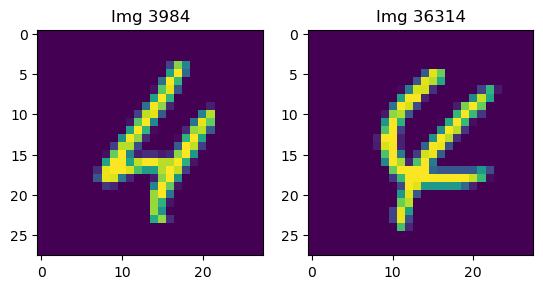

Rank 2: distXX = 36.47911834716797


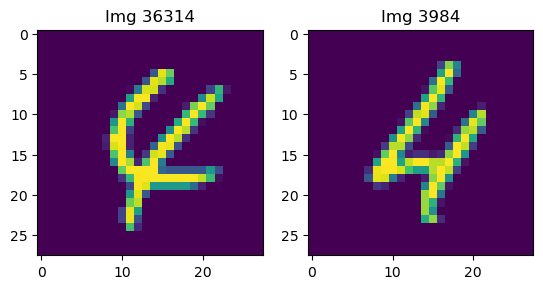

Rank 3: distXX = 44.09060287475586


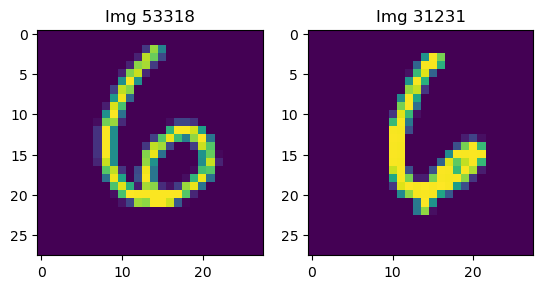

Rank 4: distXX = 44.09060287475586


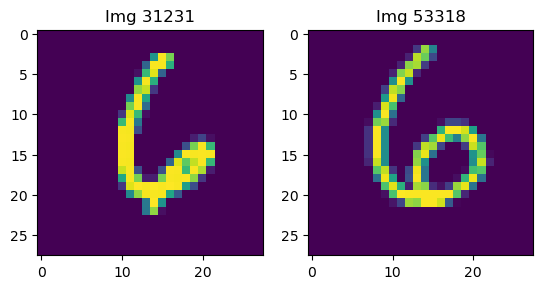

Rank 5: distXX = 34.93900680541992


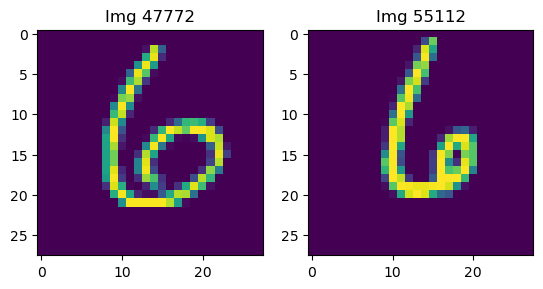

In [14]:
distsXX = torch.load(f'{MNIST_folder}/results/distsXX_MNISTalls_eps0{int(10*epsilon)}.pt')
print(f'epsilon  =  {epsilon} \n Worst Case Kersize = {distsXX.coalesce().values().max()/(28**2)}')

# Get the 5 highest values and their indices
values = distsXX.coalesce().values()
indices = distsXX.coalesce().indices()
topk = torch.topk(values, 5)
for rank in range(5):
    max_val = topk.values[rank]
    max_idx = topk.indices[rank]
    idx_pair = indices[:, max_idx].tolist()
    img1 = HR_dataset[idx_pair[0]]
    img2 = HR_dataset[idx_pair[1]]

    img1.shape

    fig, axes = plt.subplots(1,2)
    axes[0].imshow(img1)
    axes[0].set_title(f'Img {idx_pair[0]}')
    axes[1].imshow(img2)
    axes[1].set_title(f'Img {idx_pair[1]}')
    print(f'Rank {rank+1}: distXX = {np.linalg.norm(img1-img2, ord=1)}')
    plt.show()